In [54]:
import pandas as pd

train_data_encoded = pd.read_csv('../data/train_encoded.csv')
test_data_encoded = pd.read_csv('../data/test_encoded.csv')
train_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 95 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   y                         10000 non-null  int64  
 1   tariff                    10000 non-null  int64  
 2   age                       10000 non-null  float64
 3   area                      10000 non-null  int64  
 4   channel                   10000 non-null  int64  
 5   m01.out.peak.count        10000 non-null  int64  
 6   m01.out.peak.duration     10000 non-null  int64  
 7   m01.out.peak.value        10000 non-null  float64
 8   m01.out.offpeak.count     10000 non-null  int64  
 9   m01.out.offpeak.duration  10000 non-null  int64  
 10  m01.out.offpeak.value     10000 non-null  float64
 11  m01.in.count              10000 non-null  int64  
 12  m01.in.duration           10000 non-null  int64  
 13  m01.sms.count             10000 non-null  int64  
 14  m01.cus

In [55]:
# find numeriacal value
X = train_data_encoded.drop('y',axis=1)
X_test = test_data_encoded
print(f'Existing data type are {X.dtypes.unique()}')
numerical_features = []
for f in X.columns:
    if X[f].dtype in ['int64','float64']:
        numerical_features.append(f)

# cap outliers
for f in numerical_features:
    lower = X[f].quantile(0.01)
    upper = X[f].quantile(0.99)
    X[f] = X[f].clip(lower, upper)
    
    lower = X_test[f].quantile(0.01)
    upper = X_test[f].quantile(0.99)
    X_test[f] = X_test[f].clip(lower, upper)
print('Outliers have been capped at 1st and 99th percentiles')

# scale numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])
X_test[numerical_features] = scaler.fit_transform(X_test[numerical_features])
print('Columns are scaled')
# print(train_data_encoded[numerical_features].head().to_string())
# X[numerical_features].head()



Existing data type are [dtype('int64') dtype('float64') dtype('bool')]
Outliers have been capped at 1st and 99th percentiles
Columns are scaled


# Elastic Net

Training set: (8000, 94), Validation set: (2000, 94)

Training Elastic Net Regression with Cross-Validation on Training Set...


Training Progress: 100%|██████████| 00:01 elapsed


Best alpha (regularization strength): 0.01
Best l1_ratio (mix between L1 and L2): 0.1

Feature Coefficients (Elastic Net Regularization):
                  Feature  Coefficient
74     m08.out.peak.count    62.648976
64     m07.out.peak.count    39.851561
54     m06.out.peak.count    14.465038
60           m06.in.count   -12.000436
76     m08.out.peak.value   -11.778268
..                    ...          ...
84   payment_bank account     0.138135
42          m04.sms.count     0.136911
9   m01.out.offpeak.value    -0.038457
22          m02.sms.count    -0.037053
14     m02.out.peak.count    -0.027868

[94 rows x 2 columns]

Elastic Net Regression Performance on Validation Set:
Validation Mean Squared Error (MSE): 5289.51
Validation R^2 Score: 0.7515


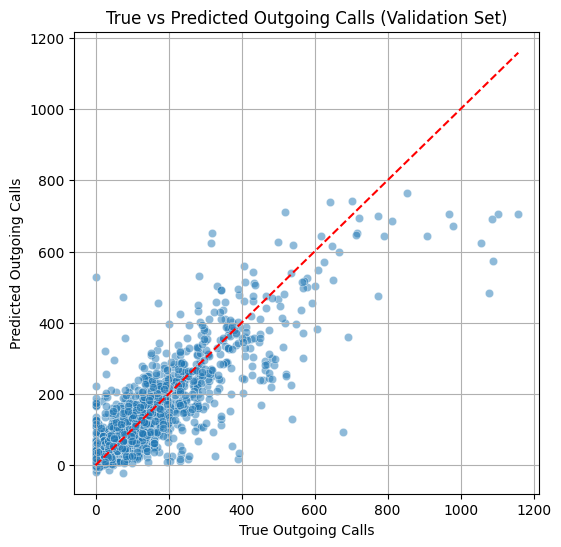

In [57]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Prepare your data
X = X  # drop target
y = train_data_encoded['y']  # target = number of outgoing calls


# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")

# Setup ElasticNetCV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 1],
    alphas=np.logspace(-2, -2, 100),
    cv=cv,
    random_state=42,
    max_iter=10000  # safer to increase iterations
)

# Progress bar
print("\nTraining Elastic Net Regression with Cross-Validation on Training Set...")
with tqdm(total=1, desc="Training Progress", bar_format="{l_bar}{bar}| {elapsed} elapsed") as pbar:
    model_elastic.fit(X_train, y_train)
    pbar.update(1)

# Best parameters
print("\nBest alpha (regularization strength):", model_elastic.alpha_)
print("Best l1_ratio (mix between L1 and L2):", model_elastic.l1_ratio_)

# Coefficients
coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model_elastic.coef_})
print("\nFeature Coefficients (Elastic Net Regularization):")
print(coeff_df.sort_values(by='Coefficient', key=abs, ascending=False))

# Predictions on validation set
y_val_pred = model_elastic.predict(X_val)

# Evaluation on validation set
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

print("\nElastic Net Regression Performance on Validation Set:")
print(f"Validation Mean Squared Error (MSE): {mse_val:.2f}")
print(f"Validation R^2 Score: {r2_val:.4f}")

# Plot true vs predicted (Validation)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val, y=y_val_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True Outgoing Calls")
plt.ylabel("Predicted Outgoing Calls")
plt.title("True vs Predicted Outgoing Calls (Validation Set)")
plt.grid(True)
plt.show()

In [ ]:
# Predict using your trained model
y_test_pred = model_elastic.predict(X_test)

# Optionally, clip predictions (no negative calls)
y_test_pred = np.clip(y_test_pred, 0, None)

# View first few predictions
print(y_test_pred[:10])

# Save predictions as a plain TXT file (one prediction per line, no header)
np.savetxt('../prediction/prediction_ElasticNet.txt', y_test_pred, fmt='%.6f')

print("Predictions saved to prediction_ElasticNet.txt!") # score = 42.41


[152.78052092  17.1260341   85.4858993   19.87630222 353.93296486
  71.69507822  86.68944496  55.02505411 116.30547959   4.65948447]
Predictions saved to prediction_ElasticNet.txt!
